# Master's Thesis Notebook

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**  
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**  
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>  
Michele Lucente <michele.lucente@unibo.it>

**Date**  
June 2026


# test8 integration

Notebook equivalent of `tests/4_earth/test8_integration.py`. The original Python test module remains the source of truth; this notebook imports it and runs each numerical test and diagnostic plot in its own cell for interactive inspection.

The notebook uses the shared TPeanuts output-root convention defined in section `2. Paths`. Generated `earth` test artifacts and figures are redirected to the notebook-specific `OUTPUT_DIR` under `OUTPUT_TEST_ROOT / "earth" / NOTEBOOK_STEM`.


## 1. Libraries and test module

This section locates the repository, imports the original `earth` test module, and reloads it so source changes are reflected when the notebook is rerun. The expected result is that the module imports without errors. Possible problems include running the notebook from outside the repository tree or missing import paths for the editable package.


In [1]:
from __future__ import annotations

import importlib
import importlib.util
import os
import sys
import traceback
from pathlib import Path

import matplotlib.pyplot as plt


from tpeanuts.util.notebooks import find_repo_root
HERE = Path.cwd().resolve()
PACKAGE_DIR = find_repo_root(HERE, folder="analysis")
print(f"PACKAGE_DIR = {PACKAGE_DIR}")

NOTEBOOK_STEM = "test8_integration"
TEST_MODULE_PATH = PACKAGE_DIR / "notebooks" / "tests" / "4_earth" / f"{NOTEBOOK_STEM}.py"
TEST_MODULE_NAME = f"notebook_tests_{TEST_MODULE_PATH.parent.name.replace('.', '_')}_{NOTEBOOK_STEM}"
if not TEST_MODULE_PATH.exists():
    raise FileNotFoundError(f"Could not find local test module: {TEST_MODULE_PATH}")
spec = importlib.util.spec_from_file_location(TEST_MODULE_NAME, TEST_MODULE_PATH)
if spec is None or spec.loader is None:
    raise ImportError(f"Could not load test module spec from {TEST_MODULE_PATH}")
TEST_MODULE = importlib.util.module_from_spec(spec)
sys.modules[TEST_MODULE_NAME] = TEST_MODULE
spec.loader.exec_module(TEST_MODULE)
print("Loaded local test module:", TEST_MODULE_PATH)

from tpeanuts.util.notebooks import build_notebook_test_runner


PACKAGE_DIR = G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Loaded local test module: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\notebooks\tests\4_earth\test8_integration.py


## 2. Paths

All outputs are rooted at `DEFAULT_OUTPUT_ROOT` unless `TPEANUTS_OUTPUT_ROOT` is defined in the environment. This notebook writes `earth` test figures and generated artifacts under `OUTPUT_TEST_ROOT / "earth" / NOTEBOOK_STEM`, while data, analysis, benchmark, and external roots follow the same shared structure used by the analysis notebooks.


In [2]:
DEFAULT_OUTPUT_ROOT = Path(r"V:\output")
OUTPUT_ROOT = Path(os.environ.get("TPEANUTS_OUTPUT_ROOT", DEFAULT_OUTPUT_ROOT))

OUTPUT_DATA_ROOT = Path(OUTPUT_ROOT / "data")
OUTPUT_ANALYSIS_ROOT = Path(OUTPUT_ROOT / "analysis")
OUTPUT_BENCHMARK_ROOT = Path(OUTPUT_ROOT / "benchmark")
OUTPUT_TEST_ROOT = Path(OUTPUT_ROOT / "test")

OUTPUT_DATA_ATMOSPHERE = Path(OUTPUT_DATA_ROOT / "atmosphere")
OUTPUT_DATA_SOLAR = Path(OUTPUT_DATA_ROOT / "solar")
OUTPUT_DATA_EXTERNAL = Path(OUTPUT_DATA_ROOT / "external")

OUTPUT_ANALYSIS_ATMOSPHERE = Path(OUTPUT_ANALYSIS_ROOT / "atmosphere")
OUTPUT_ANALYSIS_SOLAR = Path(OUTPUT_ANALYSIS_ROOT / "solar")
OUTPUT_ANALYSIS_EXTERNAL = Path(OUTPUT_ANALYSIS_ROOT / "external")

OUTPUT_DATA_MCEQ = Path(OUTPUT_DATA_ROOT / "mceq")
OUTPUT_DATA_HONDA = Path(OUTPUT_DATA_ROOT / "honda")

OUTPUT_DIR = OUTPUT_TEST_ROOT / "earth" / NOTEBOOK_STEM
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SHOW_PLOTS = True
print("Output root     :", OUTPUT_ROOT)
print("Output directory:", OUTPUT_DIR)


Output root     : V:\output
Output directory: V:\output\test\earth\test8_integration


In [3]:
NOTEBOOK_RUNNER_ATTRS = {}
if "RUN_REAL_DATA_ANALYSIS" in globals():
    NOTEBOOK_RUNNER_ATTRS["RUN_REAL_mceq_run1_analysis"] = RUN_REAL_DATA_ANALYSIS

runner = build_notebook_test_runner(
    TEST_MODULE,
    OUTPUT_DIR,
    show_plots=SHOW_PLOTS,
    auto_save_figures=True,
    extra_module_attrs=NOTEBOOK_RUNNER_ATTRS,
)
run_notebook_test = runner.run_test
run_notebook_call = runner.run_call


## Test: `test_prepare_energy_grid`

**What is checked:** Prepare energy grid behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Scalar energy must become one-element grid; Scalar energy must request squeeze; Vector energy shape must be preserved; Vector energy must not request squeeze.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [4]:
run_notebook_test(TEST_MODULE.test_prepare_energy_grid)


Running test_prepare_energy_grid ...

_prepare_energy_grid:
scalar: tensor([1.0000000000e+03], dtype=torch.float64) squeeze: True
vector: tensor([5.0000000000e+02, 1.0000000000e+03, 3.0000000000e+03, 1.0000000000e+04], dtype=torch.float64) squeeze: False
------------------------------------------------------------------------------------------
PASSED: test_prepare_energy_grid


## Test: `test_load_seeded_exposure_table`

**What is checked:** Load seeded exposure table behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Loaded eta table must have NS samples; Loaded exposure table must have NS samples; Loaded exposure must be finite.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [ ]:
run_notebook_test(TEST_MODULE.test_load_seeded_exposure_table)


## Test: `test_integrated_probabilities_match_legacy`

**What is checked:** Integrated probabilities match legacy behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Integrated torch probabilities must match legacy absolute precision; Integrated torch probabilities must match legacy relative precision; Integrated raw normalization drift must match legacy.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; legacy/reference-data comparisons may fail if optional reference inputs or conventions change; normalization failures often point to probability conservation or broadcasting issues.


In [ ]:
run_notebook_test(TEST_MODULE.test_integrated_probabilities_match_legacy)


## Test: `test_scalar_energy_output_shape`

**What is checked:** Scalar energy output shape behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Scalar integrated output must have shape (3,); Scalar integrated output must be finite.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [7]:
run_notebook_test(TEST_MODULE.test_scalar_energy_output_shape)


Running test_scalar_energy_output_shape ...

Scalar integrated probability:
tensor([1.6989136458e+01, 3.3439433943e-01, 6.2180637554e-01], dtype=torch.float64)
------------------------------------------------------------------------------------------
PASSED: test_scalar_energy_output_shape


## Test: `test_numerical_method_runs`

**What is checked:** Numerical method runs behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Numerical integrated output must have shape (3,); Numerical integrated output must be finite.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [8]:
run_notebook_test(TEST_MODULE.test_numerical_method_runs)


Running test_numerical_method_runs ...

Numerical-method integrated probability:
tensor([1.7007493305e+01, 3.3434226234e-01, 6.0169448204e-01], dtype=torch.float64)
------------------------------------------------------------------------------------------
PASSED: test_numerical_method_runs


## Plot: `plot_integrated_probability_spectra()`

**What is checked:** Integrated probability spectra behavior and numerical consistency.

**Expected result:** The expected result is that the plot call writes its diagnostic image file(s) (earth_integration_probability_spectra.png) to `OUTPUT_DIR` and displays them inline when `SHOW_PLOTS = True`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; normalization failures often point to probability conservation or broadcasting issues; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Plot output for `plot_integrated_probability_spectra()`

This block generates or validates diagnostic plot files in `OUTPUT_DIR`:

- `earth_integration_probability_spectra.png`

The expected result is that each image is written to disk and, when `SHOW_PLOTS = True`, also displayed inline in the notebook. Possible problems include a non-writable output directory, an inactive Matplotlib backend, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_integrated_probability_spectra() ...
Saved plot: V:\output\test\earth\test8_integration\plot_integrated_probability_spectra_figure_001.png


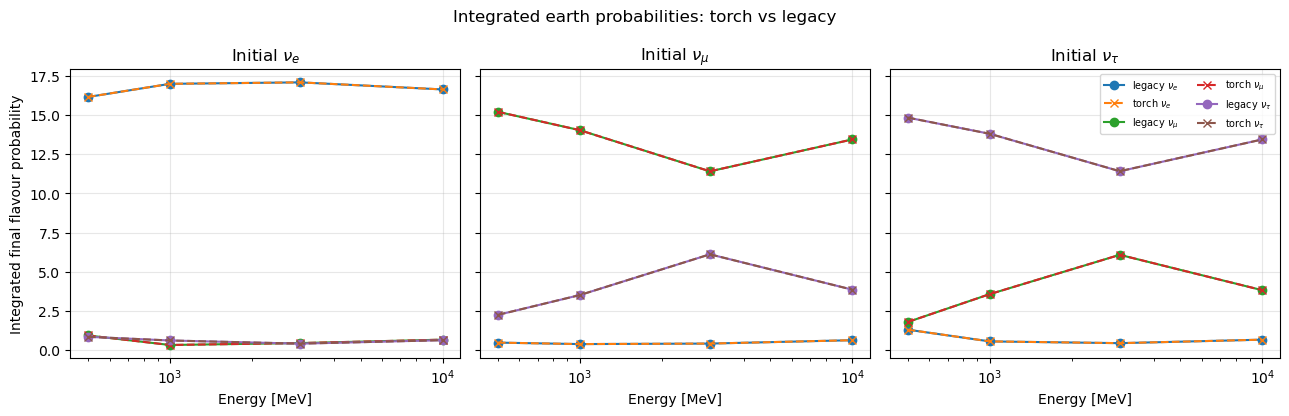

PASSED: plot_integrated_probability_spectra()


In [9]:
run_notebook_call('plot_integrated_probability_spectra()', lambda: TEST_MODULE.plot_integrated_probability_spectra())


## Plot: `plot_initial_and_final_flux_spectra()`

**What is checked:** Initial and final flux spectra behavior and numerical consistency.

**Expected result:** The expected result is that the plot call writes its diagnostic image file(s) (earth_integration_initial_final_spectra.png) to `OUTPUT_DIR` and displays them inline when `SHOW_PLOTS = True`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Plot output for `plot_initial_and_final_flux_spectra()`

This block generates or validates diagnostic plot files in `OUTPUT_DIR`:

- `earth_integration_initial_final_spectra.png`

The expected result is that each image is written to disk and, when `SHOW_PLOTS = True`, also displayed inline in the notebook. Possible problems include a non-writable output directory, an inactive Matplotlib backend, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_initial_and_final_flux_spectra() ...
Saved plot: V:\output\test\earth\test8_integration\plot_initial_and_final_flux_spectra_figure_001.png


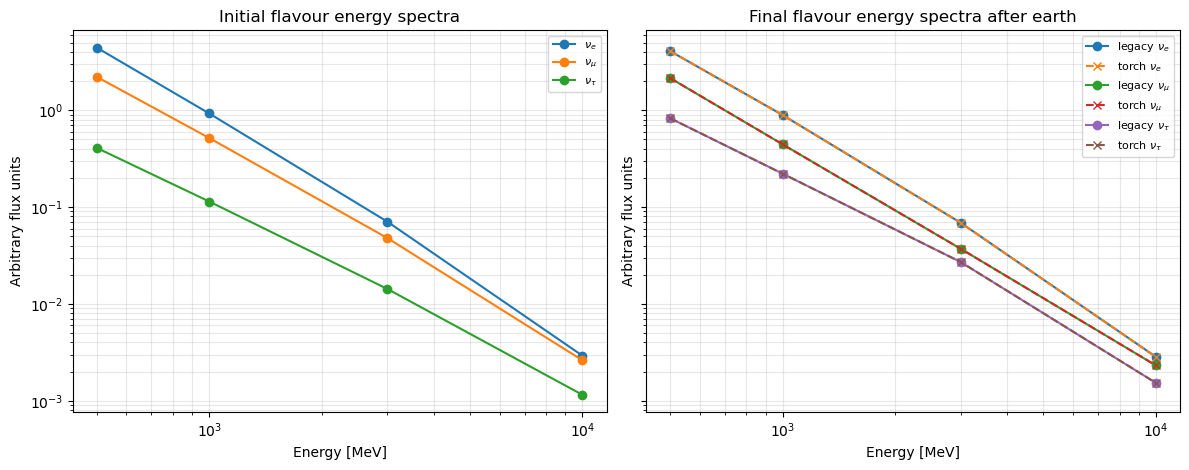

PASSED: plot_initial_and_final_flux_spectra()


In [10]:
run_notebook_call('plot_initial_and_final_flux_spectra()', lambda: TEST_MODULE.plot_initial_and_final_flux_spectra())


## Plot: `plot_integration_error_heatmap()`

**What is checked:** Integration error heatmap behavior and numerical consistency.

**Expected result:** The expected result is that the plot call writes its diagnostic image file(s) (earth_integration_error_heatmap.png) to `OUTPUT_DIR` and displays them inline when `SHOW_PLOTS = True`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Plot output for `plot_integration_error_heatmap()`

This block generates or validates diagnostic plot files in `OUTPUT_DIR`:

- `earth_integration_error_heatmap.png`

The expected result is that each image is written to disk and, when `SHOW_PLOTS = True`, also displayed inline in the notebook. Possible problems include a non-writable output directory, an inactive Matplotlib backend, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_integration_error_heatmap() ...
Saved plot: V:\output\test\earth\test8_integration\plot_integration_error_heatmap_figure_001.png


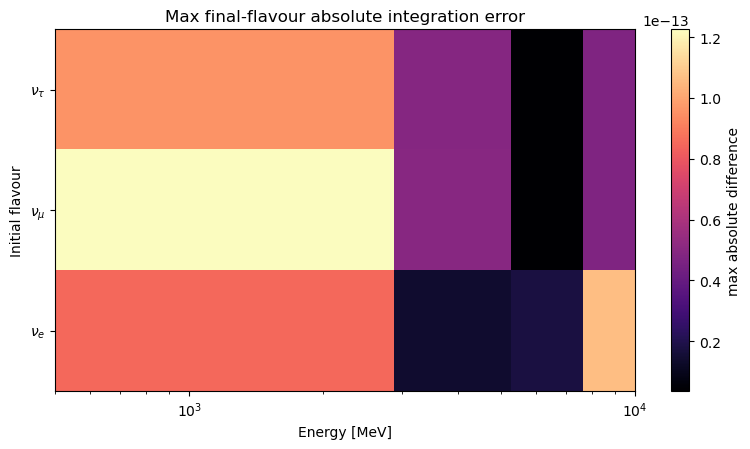

PASSED: plot_integration_error_heatmap()


In [11]:
run_notebook_call('plot_integration_error_heatmap()', lambda: TEST_MODULE.plot_integration_error_heatmap())
